# Обработка датасета Retail Store Sales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Считываем данные

In [3]:
df = pd.read_csv("retail_store_sales.csv")
print(df.head(5))
df.shape

  Transaction ID Customer ID       Category          Item  Price Per Unit  \
0    TXN_6867343     CUST_09     Patisserie   Item_10_PAT            18.5   
1    TXN_3731986     CUST_22  Milk Products  Item_17_MILK            29.0   
2    TXN_9303719     CUST_02       Butchers   Item_12_BUT            21.5   
3    TXN_9458126     CUST_06      Beverages   Item_16_BEV            27.5   
4    TXN_4575373     CUST_05           Food   Item_6_FOOD            12.5   

   Quantity  Total Spent  Payment Method Location Transaction Date  \
0      10.0        185.0  Digital Wallet   Online       2024-04-08   
1       9.0        261.0  Digital Wallet   Online       2023-07-23   
2       2.0         43.0     Credit Card   Online       2022-10-05   
3       9.0        247.5     Credit Card   Online       2022-05-07   
4       7.0         87.5  Digital Wallet   Online       2022-10-02   

  Discount Applied  
0             True  
1             True  
2            False  
3              NaN  
4          

(12575, 11)

Заполняем пропуски в датасете

In [5]:
for col in df.columns:
  print(f'В столбце {col} {df[df[col].isna()].shape[0]} пропусков')

В столбце Transaction ID 0 пропусков
В столбце Customer ID 0 пропусков
В столбце Category 0 пропусков
В столбце Item 1213 пропусков
В столбце Price Per Unit 609 пропусков
В столбце Quantity 604 пропусков
В столбце Total Spent 604 пропусков
В столбце Payment Method 0 пропусков
В столбце Location 0 пропусков
В столбце Transaction Date 0 пропусков
В столбце Discount Applied 4199 пропусков


In [46]:
df["Item"] = df["Item"].fillna("Unknown")
df["Discount Applied"] = df["Discount Applied"].fillna(False)

for r in range(df.shape[0]):
  nones = []
  for s in ["Price Per Unit", "Quantity", "Total Spent"]:
    if np.isnan(df.loc[r, s]):
      nones.append(s)
  if len(nones) == 1:
    if nones[0] == "Price Per Unit":
      df.loc[r, nones[0]] = df.loc[r, "Total Spent"] / df.loc[r, "Quantity"]
    elif nones[0] == "Quantity":
      df.loc[r, nones[0]] = df.loc[r, "Total Spent"] / df.loc[r, "Price Per Unit"]
    else:
      df.loc[r, nones[0]] = df.loc[r, "Price Per Unit"] * df.loc[r, "Quantity"]
  elif len(nones) > 1:
    for s in nones:
      df.loc[r, s] = 0.0

In [47]:
for col in df.columns:
  print(f'В столбце {col} {df[df[col].isna()].shape[0]} пропусков')

В столбце Transaction ID 0 пропусков
В столбце Customer ID 0 пропусков
В столбце Category 0 пропусков
В столбце Item 0 пропусков
В столбце Price Per Unit 0 пропусков
В столбце Quantity 0 пропусков
В столбце Total Spent 0 пропусков
В столбце Payment Method 0 пропусков
В столбце Location 0 пропусков
В столбце Transaction Date 0 пропусков
В столбце Discount Applied 0 пропусков


Заполняем пропуски в "Item" и "Discount Applied" значениями "Unknown" и "False" соответственно.<br>
Значения "Price Per Unit", "Quantity" и "Total Spent" связаны формулой $$ Total Spent = PricePerUnit \cdot Quantity$$
Следовательно, если нам неизвестно только одно из них, то заполняем по формуле. Иначе вставляем 0.0

Проверим типы данных:

In [48]:
for col in df.columns:
  print(f"{col}: {pd.api.types.infer_dtype(df[col])}")

Transaction ID: string
Customer ID: string
Category: string
Item: string
Price Per Unit: floating
Quantity: floating
Total Spent: floating
Payment Method: string
Location: string
Transaction Date: datetime64
Discount Applied: boolean


In [49]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"])

Удаляем повторяющиеся строки

In [109]:
orig_shape = df.shape[0]
df = df.drop_duplicates()
print(f'Удалили {orig_shape - df.shape[0]} строк-дубликатов')

Удалили 0 строк-дубликатов


In [51]:
if df["Transaction ID"].unique().shape[0] == df.shape[0]:
  print("Все ID транзакций различны")
else:
  print("Есть дубликаты ID транзакций")

Все ID транзакций различны


Удалим выбросы в Total Spent:

In [58]:
from cycler import L
Q1, Q3 = np.quantile(df["Total Spent"], [0.25, 0.75])
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
up = Q3 + 1.5 * IQR
df = df[(low <= df["Total Spent"]) & (df["Total Spent"] <= up)]

## Визуализация и анализ данных

In [84]:
df_by_date = df.groupby(df["Transaction Date"].dt.to_period("M"))["Total Spent"].sum()
print(f'Период транзакций: {min(df_by_date.index)} - {max(df_by_date.index)}')

Период транзакций: 2022-01 - 2025-01


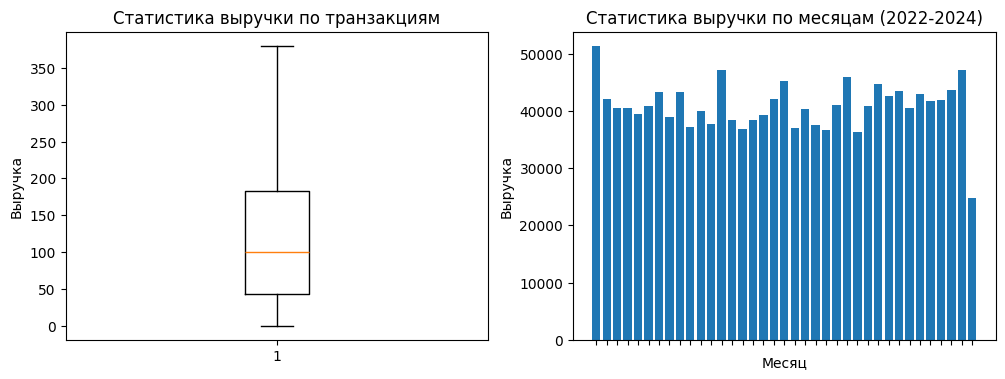

In [87]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.boxplot(df["Total Spent"].values)
ax1.set_ylabel("Выручка")
ax2.bar(df_by_date.index.astype(str), df_by_date.values)
ax2.set_xlabel("Месяц")
ax2.set_ylabel("Выручка")
ax1.set_title("Статистика выручки по транзакциям")
ax2.set_title("Статистика выручки по месяцам (2022-2024)")
ax2.set_xticklabels([])
plt.show()

In [88]:
print(f'Средняя выручка: {df["Total Spent"].mean():.2f}')
print(f'Сдвиг выручки: {df["Total Spent"].std():.2f}')

Средняя выручка: 121.20
Сдвиг выручки: 93.59


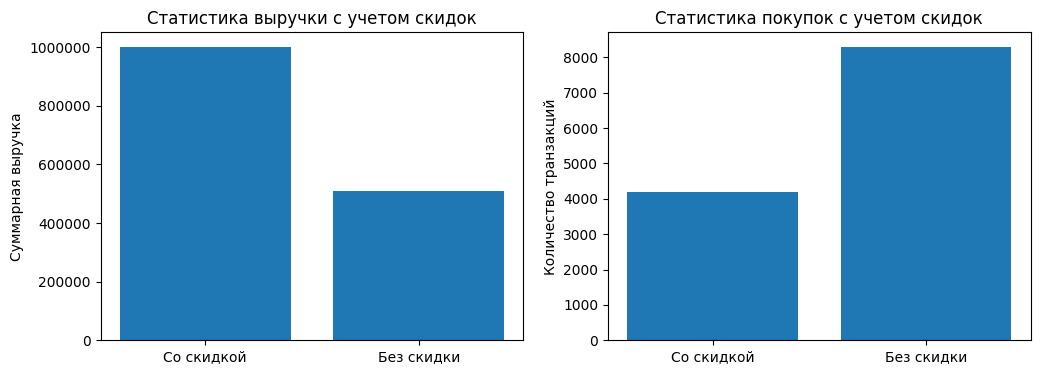

In [99]:
discount_df = df.groupby(df["Discount Applied"])["Total Spent"].sum()
discount_cnt = df[df["Discount Applied"] == True].shape[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.bar(["Со скидкой", "Без скидки"], discount_df.values)
ax1.set_ylabel("Суммарная выручка")
ax1.set_title("Статистика выручки с учетом скидок")
ax1.ticklabel_format(axis="y", style='plain')
ax2.bar(["Со скидкой", "Без скидки"], [discount_cnt, df.shape[0] - discount_cnt])
ax2.set_ylabel("Количество транзакций")
ax2.set_title("Статистика покупок с учетом скидок")
plt.show()

In [108]:
print('Статистика покупателей:')
df.groupby('Customer ID').agg({
    'Customer ID': 'count',
    'Total Spent': 'sum'
}).rename(columns={'Customer ID': 'Кол-во транзакций', 'Total Spent': 'Сумма покупок'}).sort_values(by="Кол-во транзакций", ascending=False)

Статистика покупателей:


,Кол-во транзакций,Сумма покупок
Customer ID,,
CUST_05,540,65379.5
CUST_24,538,66432.0
CUST_13,531,63822.0
CUST_08,527,64936.5
CUST_15,517,62312.5
CUST_09,515,59828.5
CUST_23,510,63292.0
CUST_16,508,62715.5
CUST_01,504,57501.5


**Вывод:** <br>
* **Обработан** датасет с 12575 строками и 11 столбцами
* Заполнены все **пропущенные значения**
* Приведены **типы данных** в каждом столбце
* Удалены **дубликаты**
* Созданы **графики**, отражающие показатели выручки и влияния скидок
* Выведены **статистики** выручки по транзакциям и клиентам